# Estatística 1 - Aula prática 3_1 em Python

## UNIDADE 3: Distribuições de probabilidade

### Seção 3.1: Distribuições discretas

By Jose P. Leitão

#### Distribuição binomial

In [4]:
# Importar bibliotecas
import pandas as pd

import numpy as np

from scipy.stats import binom, poisson, geom, hypergeom, nbinom

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Exemplo do slide: x = 0; n = 10; p = 0.3; 
# Resultado = 2.82%

# Cria uma tabela de distribuição binomial com 11 valores, onde 
# Parâmetros da distribuição binomial
n = 10  # Número de tentativas
p = 0.3 # Probabilidade de sucesso em cada tentativa

# 1. Gerar os possíveis números de sucessos (de 0 até n)
k = np.arange(0, n + 1)

# 2. Calcular a Probabilidade Mass Function (PMF) - Probabilidade exata
pmf = binom.pmf(k, n, p)

# 4. Criar o DataFrame (Tabela) com Pandas
tabela_binomial = pd.DataFrame({
    'Sucessos (k)': k,
    'P(X = k) [PMF]': pmf
})

# Formatar a saída para melhor visualização (opcional)
pd.options.display.float_format = '{:,.5f}'.format

print(f"Tabela de Distribuição Binomial (n={n}, p={p})")
print("-" * 45)
print(tabela_binomial.to_string(index=False))

Tabela de Distribuição Binomial (n=10, p=0.3)
---------------------------------------------
 Sucessos (k)  P(X = k) [PMF]
            0         0.02825
            1         0.12106
            2         0.23347
            3         0.26683
            4         0.20012
            5         0.10292
            6         0.03676
            7         0.00900
            8         0.00145
            9         0.00014
           10         0.00001


In [6]:
# Se olharmos na tabela para o experimento "zero" o valor eh
# "0.0282475249" que eh a mesma coisa que "2,82%"

In [7]:
# Outra forma de fazer

prob = binom.pmf(n=10, p=0.3, k=0)
print(f"Probabilidade {prob:.2%}")

Probabilidade 2.82%


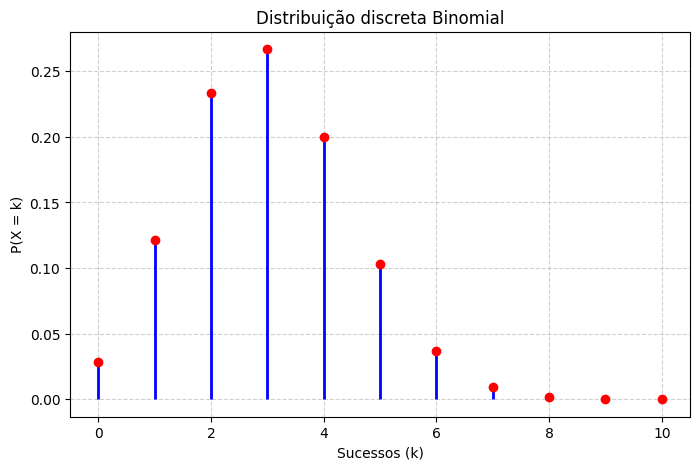

In [8]:
# Para gerar um grafico das 11 primeiras probs:
x = tabela_binomial['Sucessos (k)']
y = tabela_binomial['P(X = k) [PMF]']

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta Binomial")
plt.xlabel("Sucessos (k)")
plt.ylabel("P(X = k)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Distribuição de Poisson

In [9]:
# Exemplo do slide:lambda = 5; x = 3; resultado 14.04%

# Cria uma tabela de distribuição de Poisson com 6 valores, onde 
# ==============================
# Parâmetros da distribuição
# ==============================
lambda_val = 5   # média esperada de eventos (λ)
max_k = 13        # valor máximo de k para a tabela

# ==============================
# Geração da tabela
# ==============================
# Valores de k (número de eventos)
k_values = np.arange(0, max_k + 1)

# PMF: Probabilidade de exatamente k eventos
pmf_values = poisson.pmf(k_values, mu=lambda_val)

# Monta DataFrame para visualização
tabela_poisson = pd.DataFrame({
    'k (eventos)': k_values,
    'P(X = k)': pmf_values
})

# Formata para melhor leitura
tabela_poisson['P(X = k)'] = tabela_poisson['P(X = k)'].round(6)

print("Tabela de Distribuição de Poisson (λ = {})".format(lambda_val))
print(tabela_poisson.to_string(index=False))

Tabela de Distribuição de Poisson (λ = 5)
 k (eventos)  P(X = k)
           0   0.00674
           1   0.03369
           2   0.08422
           3   0.14037
           4   0.17547
           5   0.17547
           6   0.14622
           7   0.10444
           8   0.06528
           9   0.03627
          10   0.01813
          11   0.00824
          12   0.00343
          13   0.00132


In [10]:
# Se olharmos na tabela a linha "3" que se refere ao numero de
# chamadas recebidas (evento) encontramos "0.14037" que eh
# a mesma coisa que "14,04%"

In [11]:
##### Calculando de outra forma

prob = poisson.pmf(3, mu=5)
print(f"Probabilidade {prob:.2%}")

Probabilidade 14.04%


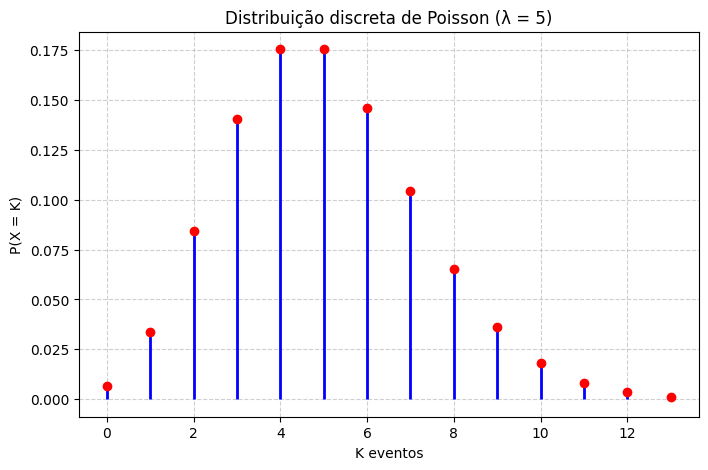

In [12]:
# Para gerar grafico das 6 primeiras probabilidades:
x = tabela_poisson['k (eventos)']
y = tabela_poisson['P(X = k)']

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta de Poisson (λ = 5)")
plt.xlabel("K eventos")
plt.ylabel("P(X = K)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#### Distribuição geométrica

In [13]:
########### Numero de fracassos ate primeiro sucesso ############

# Exemplo do slide: Y=k=2; p = 0.4; Resultado = 14,40%

In [14]:
# Cria uma tabela de distribuição geométrica com 6 valores, onde 
# Parâmetros da distribuição 

# ==============================
# Geração da tabela
# ==============================
# Valores de k (número de eventos)
# Parâmetros
p = 0.4  # Probabilidade de sucesso em cada tentativa
n_tentativas = 6  # Número de tentativas


# Gerar o número de tentativas (1, 2, ..., n_tentativas)
k = list(range(1, n_tentativas))
falhas = list(range(0, n_tentativas -1))

# Calcular PMF: P(X = k) - Probabilidade do primeiro sucesso na tentativa k
pmf = geom.pmf(k, p)

# Criar um DataFrame (Tabela)
tabela_geom = pd.DataFrame({
    'Tentativas (k)': k,
    'Falhas': falhas,
    'P(X = k) [PMF]': pmf
})

# Formatar a tabela para melhor visualização (opcional)
pd.options.display.float_format = '{:,.4f}'.format
print(f"Tabela de Distribuição Geométrica (p={p}):")
print(tabela_geom.to_string(index=False))

Tabela de Distribuição Geométrica (p=0.4):
 Tentativas (k)  Falhas  P(X = k) [PMF]
              1       0          0.4000
              2       1          0.2400
              3       2          0.1440
              4       3          0.0864
              5       4          0.0518


In [15]:
# Se olharmos na tabela a linha  que corresponde ao númeoro de falhas  "2" vamos encontrar
# "0.1440" que eh a mesma coisa que "14,40%"

In [16]:
#### Calculando de outra forma
prob = geom.pmf(2+1, 0.4) # o '+1' é para indicar o número de tentativas
print(f"Probabilidade {prob:.2%}")

Probabilidade 14.40%


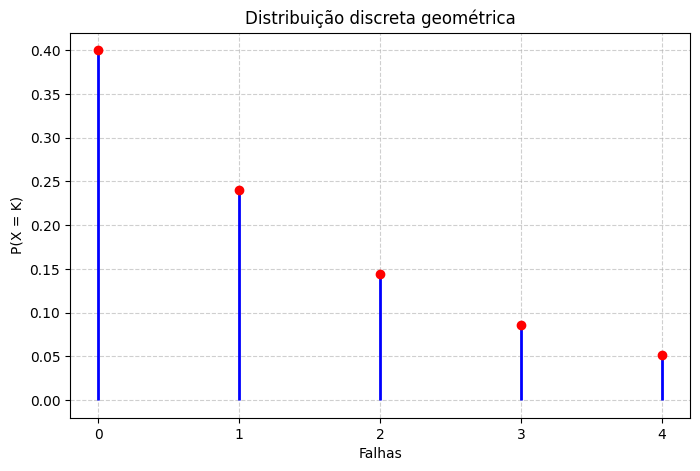

In [17]:
# Para gerar um grafico das 6 primeiras probs.
x = tabela_geom['Falhas']
y = tabela_geom['P(X = k) [PMF]']

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta geométrica")
plt.xlabel("Falhas")
plt.ylabel("P(X = K)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()




In [18]:
######## Numero de tentativas necessarias para se obter ######### 
#################### o primeiro sucesso #########################

# Exemplo do slide: p = 0.10; Y = k = 34 ==> K-1=33 ; 
# Resultado 0.31%

In [19]:
# Calculando a probabilidade
# ==============================
# Geração da tabela
# ==============================
# Valores de k (número de eventos)
# Parâmetros
p = 0.1  # Probabilidade de sucesso em cada tentativa
n_tentativas = 40  # Número de tentativas


# Gerar o número de tentativas (1, 2, ..., n_tentativas)
k = list(range(1, n_tentativas))


# Calcular PMF: P(X = k) - Probabilidade do primeiro sucesso na tentativa k
pmf = geom.pmf(k, p)

# Criar um DataFrame (Tabela)
tabela_geom = pd.DataFrame({
    'Tentativas (k)': k,
    'P(X = k) [PMF]': pmf
})

# Formatar a tabela para melhor visualização (opcional)
pd.options.display.float_format = '{:,.4f}'.format
print(f"Tabela de Distribuição Geométrica (p={p}):")
print(tabela_geom.to_string(index=False))

Tabela de Distribuição Geométrica (p=0.1):
 Tentativas (k)  P(X = k) [PMF]
              1          0.1000
              2          0.0900
              3          0.0810
              4          0.0729
              5          0.0656
              6          0.0590
              7          0.0531
              8          0.0478
              9          0.0430
             10          0.0387
             11          0.0349
             12          0.0314
             13          0.0282
             14          0.0254
             15          0.0229
             16          0.0206
             17          0.0185
             18          0.0167
             19          0.0150
             20          0.0135
             21          0.0122
             22          0.0109
             23          0.0098
             24          0.0089
             25          0.0080
             26          0.0072
             27          0.0065
             28          0.0058
             29          0.00

In [20]:
# Na tabela gerada, se olharmos a linha de numero "34" 
# encontraremos o valor de "0.003090315" que eh a mesma coisa
# que "0,31%" 

In [21]:
### Calculando de outra forma
prob = geom.pmf(34, 0.1) 
print(f"Probabilidade {prob:.2%}")

Probabilidade 0.31%


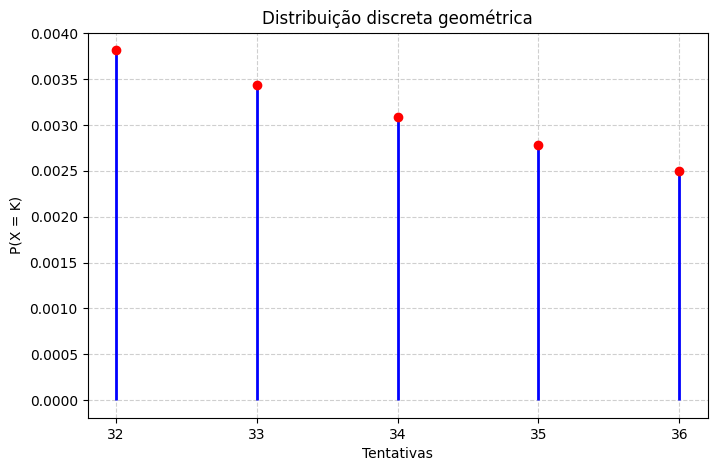

In [22]:
# Para gerar um grafico com as probs. de 30 a 35:
x = tabela_geom.loc[31:35,['Tentativas (k)']]
y = tabela_geom.loc[31:35,['P(X = k) [PMF]']]

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta geométrica")
plt.xlabel("Tentativas")
plt.ylabel("P(X = K)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

#### Distribuição hipergeométrica


In [23]:
# Exemplo do slide: 

# Resultado = 60%

In [24]:
# Calculando a probabilidade
# ==============================
# Geração da tabela
# ==============================
M = 6 # Tamanho da população
n = 3 # Total de sucessos na população
N = 4 # Tamanho da amostra


# Gerar o número de sucessos
k = list(range(0, 4))

# Calcular PMF: P(X = k)
pmf = hypergeom.pmf(k, M, n, N)

# Criar um DataFrame (Tabela)
tabela_hypergeom = pd.DataFrame({
    'Sucessos (k)': k,
    'P(X = k) [PMF]': pmf
})

# Formatar a tabela para melhor visualização (opcional)
pd.options.display.float_format = '{:,.4f}'.format
print(f"Tabela de Distribuição Hipergeométrica")
print(tabela_hypergeom.to_string(index=False))

Tabela de Distribuição Hipergeométrica
 Sucessos (k)  P(X = k) [PMF]
            0          0.0000
            1          0.2000
            2          0.6000
            3          0.2000


In [25]:
# Se olharmos na tabela a linha "2" teremos "0.6" que eh a mesma
# coisa que 60%

In [26]:
# Calculando de outra forma:
M = 6 # Tamanho da população
n = 3 # Total de sucessos na população
N = 4 # Tamanho da amostra
k = 2 # Número de sucessos
prob = hypergeom.pmf(2, M, n, N)
print(f"Probabilidade {prob:.2%}")


Probabilidade 60.00%


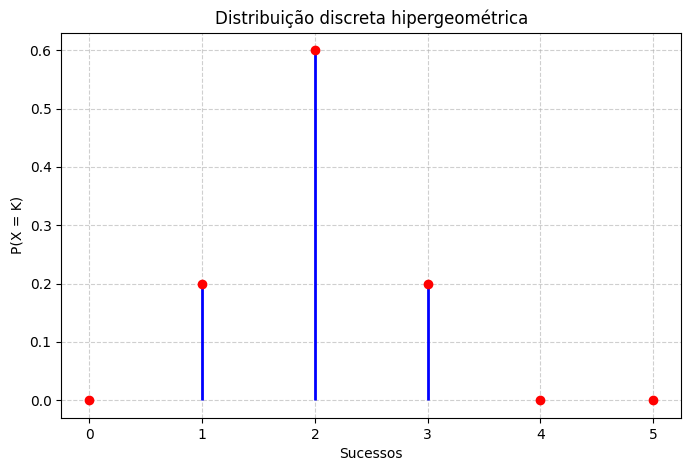

In [27]:
# Para gerar um grafico com as 6 primeiras probs:
M = 6 # Tamanho da população
n = 3 # Total de sucessos na população
N = 4 # Tamanho da amostra
k = range(0,6) # Número de sucessos

x = k
y = hypergeom.pmf(k, M, n, N)

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta hipergeométrica")
plt.xlabel("Sucessos")
plt.ylabel("P(X = K)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

#### Distribuição Binomial Negativa ( Inversa)

In [28]:
# Exemplo do slide: 
# x = 10; k=numero sucessos= size=3; p = 0.02; Resposta = 0.025% 

In [29]:
# Calculando a probabilidade
# ==============================
# Geração da tabela
# ==============================
n = 3 # Número de sucesso
p = 0.02 # Probabilidade de sucesso

# Gerar o número de sucessos
k = list(range(0, 11))

# Calcular PMF: P(X = k)
pmf = nbinom.pmf(k, n, p)

# Criar um DataFrame (Tabela)
tabela_nbinom = pd.DataFrame({
    'Sucessos (k)': k,
    'P(X = k) [PMF]': pmf
})

# Formatar a tabela para melhor visualização (opcional)
pd.options.display.float_format = '{:,.11f}'.format
print(f"Tabela de Distribuição Binomial Negativa")
print(tabela_nbinom.to_string(index=False))

Tabela de Distribuição Binomial Negativa
 Sucessos (k)  P(X = k) [PMF]
            0   0.00000800000
            1   0.00002352000
            2   0.00004609920
            3   0.00007529536
            4   0.00011068418
            5   0.00015185869
            6   0.00019842869
            7   0.00025002015
            8   0.00030627469
            9   0.00036684902
           10   0.00043141444


In [30]:
# No resultado devemos ler a observacao "7", pois 10-3=7 , dado
# que a distribuicao eh negativa (inversa), nesta linha 
# acharemos "0.00025002015" que eh a mesma coisa que 0,025%.

In [31]:
# Calculando de outra forma:
prob = nbinom.pmf(7, 3, 0.02)
print(f"Probabilidade {prob:.3%}")

Probabilidade 0.025%


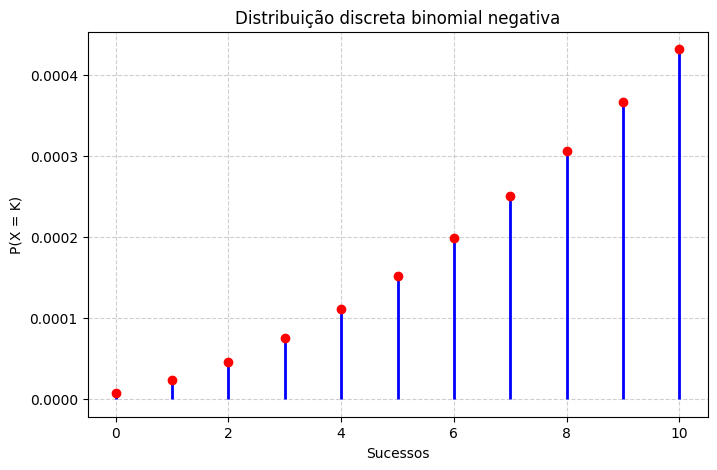

In [32]:
# Para gerar um grafico das 11 primeiras probs:
n = 3 # Número de sucesso
p = 0.02 # Probabilidade de sucesso
k = list(range(0, 11))

x = k
y = nbinom.pmf(k, n, p)

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=y, colors='blue', linewidth=2)
plt.scatter(x, y, color='red', zorder=3)  # marcadores no topo das hastes

plt.title("Distribuição discreta binomial negativa")
plt.xlabel("Sucessos")
plt.ylabel("P(X = K)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()